# Wizualizacja detekcji keypointów i nałożenia siatki boiska

Notebook pomocniczy do przygotowania ilustracji do podrozdziału **5.3.2**.

Notebook wykonuje dwa kroki:
1. wczytuje pojedynczy obraz i uruchamia model **YOLOv8x-pose** do detekcji 32 punktów charakterystycznych boiska,
2. estymuje macierz homografii i nakłada na obraz siatkę / model boiska przetransformowany do perspektywy transmisji.

Domyślnie korzysta z implementacji z projektu `CvFootballTracker`.

In [55]:
from pathlib import Path
import sys
import math
import zipfile
import subprocess

# --- (Opcjonalnie) instalacja zależności ---
# Odkomentuj poniższą linię, jeśli uruchamiasz notebook w nowym środowisku.
# !pip install ultralytics opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Ścieżki do projektu ---
# Jeśli notebook jest w folderze 'notebooks', to katalog nadrzędny jest rootem projektu
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    PROJECT_ROOT = current_dir.parent
else:
    # Alternatywnie szukaj CvFootballTracker w bieżącym katalogu
    PROJECT_ROOT = current_dir / 'CvFootballTracker'
    if not PROJECT_ROOT.exists():
        PROJECT_ROOT = current_dir.parent / 'CvFootballTracker'

if not PROJECT_ROOT.exists() or not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError(f'Nie znaleziono katalogu projektu. Przeszukano: {current_dir} i {current_dir.parent}')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Wagi modelu keypoints (ścieżka względna) ---
MODEL_WEIGHTS = PROJECT_ROOT / 'models' / 'pitch_keypoints' / 'trained_keypoints.pt'

# --- Obraz wejściowy (ścieżka względna) ---
# ⚠️ WAŻNE: Model keypoints był trenowany na tracking_dataset, nie calibration_dataset!
# Tak jak w pipeline'u: tracking_dataset/tracking/test/SNMOT-XXX/img1/
# Znajdź pierwszy dostępny plik jpg
FRAMES_DIR = PROJECT_ROOT / 'data' / 'calibration_dataset' / 'calibration' / 'test' 
frame_files = sorted(FRAMES_DIR.glob('*.jpg')) if FRAMES_DIR.exists() else []

if len(frame_files) == 0:
    raise FileNotFoundError(f'Brak plików jpg w: {FRAMES_DIR}')

IMAGE_PATH = frame_files[2]
print(f'Wybrana klatka: {IMAGE_PATH.name}')

# --- Ustawienia wyjścia ---
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'keypoints_visualization'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('MODEL_WEIGHTS =', MODEL_WEIGHTS)
print('IMAGE_PATH =', IMAGE_PATH)
print('OUTPUT_DIR =', OUTPUT_DIR)

Wybrana klatka: 00002.jpg
PROJECT_ROOT = c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker
MODEL_WEIGHTS = c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\models\pitch_keypoints\trained_keypoints.pt
IMAGE_PATH = c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\data\calibration_dataset\calibration\test\00002.jpg
TARGET_RESOLUTION = 1920×1080
OUTPUT_DIR = c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\results\keypoints_visualization


In [56]:
from src.calibration.keypoints_homography import (
    KeypointsHomography,
    PITCH_KEYPOINTS_TEMPLATE_M,
    KEYPOINT_CONFIDENCE_THRESHOLD,
    RANSAC_REPROJ_THRESHOLD,
    PITCH_HALF_LENGTH_M,
    PITCH_HALF_WIDTH_M,
)

# --- Załaduj KeypointsHomography jak w pipeline'u ---
print(f'Ładowanie KeypointsHomography z: {MODEL_WEIGHTS}')
if not MODEL_WEIGHTS.exists():
    raise FileNotFoundError(f'Model nie znaleziony: {MODEL_WEIGHTS}')

calibrator = KeypointsHomography(model_weights=str(MODEL_WEIGHTS))
print(f'✅ KeypointsHomography załadowany pomyślnie')

Ładowanie KeypointsHomography z: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\models\pitch_keypoints\trained_keypoints.pt
[KeypointsHomography] Urządzenie: cpu
[KeypointsHomography] Wczytywanie modelu: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\models\pitch_keypoints\trained_keypoints.pt
[KeypointsHomography] Model gotowy ✓
✅ KeypointsHomography załadowany pomyślnie


In [54]:
# --- Debugowanie: sprawdzenie czy pliki istnieją ---
print('=== DEBUG: Sprawdzenie plików ===')
print(f'MODEL_WEIGHTS istnieje: {MODEL_WEIGHTS.exists()}')
print(f'IMAGE_PATH istnieje: {IMAGE_PATH.exists()}')

if MODEL_WEIGHTS.exists():
    print(f'Rozmiar pliku wag: {MODEL_WEIGHTS.stat().st_size / 1024 / 1024:.2f} MB')
else:
    print(f'❌ BRAK PLIKU WAG: {MODEL_WEIGHTS}')

if IMAGE_PATH.exists():
    print(f'Rozmiar obrazu: {IMAGE_PATH.stat().st_size / 1024:.2f} KB')
    # Spróbuj wczytać obraz
    test_img = cv2.imread(str(IMAGE_PATH))
    if test_img is not None:
        print(f'Obraz wczytany pomyślnie, rozmiar: {test_img.shape}')
    else:
        print(f'❌ Nie udało się wczytać obrazu')
else:
    print(f'❌ BRAK OBRAZU: {IMAGE_PATH}')

# Sprawdzenie załadowanego modelu
print(f'\n✅ Model YOLO załadowany pomyślnie')
print(f'Model: {type(model).__name__}')

=== DEBUG: Sprawdzenie plików ===
MODEL_WEIGHTS istnieje: True
IMAGE_PATH istnieje: True
Rozmiar pliku wag: 133.68 MB
Rozmiar obrazu: 158.46 KB
Obraz wczytany pomyślnie, rozmiar: (540, 960, 3)

✅ Model YOLO załadowany pomyślnie
Model: YOLO


## Detekcja punktów charakterystycznych

Poniższa komórka uruchamia model na obrazie, a następnie tworzy wizualizację punktów.
Kolorem zielonym oznaczane są punkty, które przeszły próg pewności i zostały użyte do estymacji homografii,
kolorem czerwonym — punkty odrzucone.

In [57]:
image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise FileNotFoundError(f'Nie udało się wczytać obrazu: {IMAGE_PATH}')
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# --- Użyj metody calibrator.get_homography() jak w pipeline'u ---
print(f'Uruchamianie detekcji keypointów na: {IMAGE_PATH}')
H = calibrator.get_homography(str(IMAGE_PATH))

if H is None:
    raise RuntimeError('Brak detekcji keypoints - obraz może nie zawierać wyraźnie widocznych linii boiska')

print(f'✅ Homografia wyznaczona pomyślnie')
print(f'Macierz homografii H:\n{H}')

# --- Wyciągnij keypoints z modelu do wizualizacji ---
# Uruchom model YOLO bezpośrednio na obrazie
from ultralytics import YOLO
model_pose = YOLO(str(MODEL_WEIGHTS), task='pose')
results = model_pose(str(IMAGE_PATH), verbose=False)

if len(results) > 0 and results[0].keypoints is not None and results[0].keypoints.data.shape[0] > 0:
    keypoints_tensor = results[0].keypoints.data[0]
    keypoints = keypoints_tensor.cpu().numpy() if hasattr(keypoints_tensor, 'cpu') else keypoints_tensor.numpy()
    
    confident_mask = keypoints[:, 2] >= KEYPOINT_CONFIDENCE_THRESHOLD
    n_confident = int(confident_mask.sum())
    print(f'Liczba pewnych keypointów (conf >= {KEYPOINT_CONFIDENCE_THRESHOLD}): {n_confident}')
    
    # Wizualizacja
    kp_vis = image_rgb.copy()
    for idx, (x, y, conf) in enumerate(keypoints):
        x_i, y_i = int(round(x)), int(round(y))
        color = (0, 255, 0) if confident_mask[idx] else (255, 0, 0)
        cv2.circle(kp_vis, (x_i, y_i), 6, color, -1)
        cv2.circle(kp_vis, (x_i, y_i), 8, (255, 255, 255), 1)
        cv2.putText(
            kp_vis,
            str(idx),
            (x_i + 6, y_i - 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_AA,
        )

    plt.figure(figsize=(14, 8))
    plt.imshow(kp_vis)
    plt.title('Wykryte punkty charakterystyczne boiska')
    plt.axis('off')
    plt.show()
else:
    print('⚠️ Brak keypoints do wizualizacji na tym obrazie, ale homografia została wyznaczona')
    keypoints = None
    confident_mask = np.array([])
    n_confident = 0

Rozmiar oryginalny: 960×540
⚠️ Przeskalowanie z 960×540 do 1920×1080
✅ Nowy rozmiar: 1920×1080
Uruchamianie detekcji keypointów na: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\data\calibration_dataset\calibration\test\00002.jpg
[KeypointsHomography] Brak detekcji boiska w: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\data\calibration_dataset\calibration\test\00002.jpg


Rozmiar oryginalny: 960×540
⚠️ Przeskalowanie z 960×540 do 1920×1080
✅ Nowy rozmiar: 1920×1080
Uruchamianie detekcji keypointów na: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\data\calibration_dataset\calibration\test\00002.jpg
[KeypointsHomography] Brak detekcji boiska w: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\data\calibration_dataset\calibration\test\00002.jpg


RuntimeError: Brak detekcji keypoints - obraz może nie zawierać wyraźnie widocznych linii boiska

## Estymacja homografii

Najpierw wybierane są punkty o dostatecznej pewności, a następnie wyznaczana jest homografia metodą **RANSAC**.
Dodatkowo poniżej zapisuję maskę inlierów, żeby można było sprawdzić, które punkty zostały wykorzystane przez algorytm.

In [51]:
if n_confident < 4:
    raise RuntimeError('Za mało pewnych punktów do estymacji homografii.')

src_pts = keypoints[confident_mask, :2].astype(np.float32)
dst_pts = PITCH_KEYPOINTS_TEMPLATE_M[confident_mask].astype(np.float32)

H, inlier_mask = cv2.findHomography(
    src_pts,
    dst_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=RANSAC_REPROJ_THRESHOLD,
)

if H is None:
    raise RuntimeError('Nie udało się wyznaczyć homografii.')

inlier_mask = inlier_mask.ravel().astype(bool) if inlier_mask is not None else np.zeros(len(src_pts), dtype=bool)
print('Homografia H (image -> pitch):')
print(H)
print(f'Liczba inlierów RANSAC: {int(inlier_mask.sum())} / {len(inlier_mask)}')

Homografia H (image -> pitch):
[[    0.18342    0.022758     -168.17]
 [    0.01069     0.33664     -188.92]
 [ -0.0015732   0.0052283           1]]
Liczba inlierów RANSAC: 10 / 15


## Funkcje pomocnicze do rysowania modelu boiska

Model boiska tworzony jest w układzie metrycznym zgodnym z implementacją projektu:
- długość: **105 m**,
- szerokość: **68 m**,
- środek boiska: **(0, 0)**.

Aby nałożyć siatkę na obraz, wykorzystujemy macierz odwrotną do homografii, czyli mapowanie
**z modelu boiska do obrazu**.

In [52]:
# --- Stałe geometrii boiska (metry) ---
PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
PENALTY_AREA_LEN = 16.5
PENALTY_AREA_W = 40.32
GOAL_AREA_LEN = 5.5
GOAL_AREA_W = 18.32
CENTER_CIRCLE_R = 9.15
PENALTY_SPOT_DIST = 11.0
PENALTY_ARC_R = 9.15


def sample_arc(center_x, center_y, radius, angle_start_deg, angle_end_deg, n=80):
    angles = np.deg2rad(np.linspace(angle_start_deg, angle_end_deg, n))
    xs = center_x + radius * np.cos(angles)
    ys = center_y + radius * np.sin(angles)
    return np.column_stack([xs, ys]).astype(np.float32)


def sample_circle(center_x, center_y, radius, n=180):
    return sample_arc(center_x, center_y, radius, 0, 360, n=n)


def line(points):
    return np.array(points, dtype=np.float32)


def build_pitch_primitives():
    xL, xR = -PITCH_LENGTH / 2, PITCH_LENGTH / 2
    yT, yB = -PITCH_WIDTH / 2, PITCH_WIDTH / 2

    primitives = []

    # Kontur boiska
    primitives.append(line([[xL, yT], [xR, yT], [xR, yB], [xL, yB], [xL, yT]]))

    # Linia środkowa
    primitives.append(line([[0.0, yT], [0.0, yB]]))

    # Koło środkowe
    primitives.append(sample_circle(0.0, 0.0, CENTER_CIRCLE_R, n=200))

    # Lewa strona
    x_pen_l = xL + PENALTY_AREA_LEN
    x_goal_l = xL + GOAL_AREA_LEN
    primitives.append(line([[xL, -PENALTY_AREA_W/2], [x_pen_l, -PENALTY_AREA_W/2], [x_pen_l, PENALTY_AREA_W/2], [xL, PENALTY_AREA_W/2]]))
    primitives.append(line([[xL, -GOAL_AREA_W/2], [x_goal_l, -GOAL_AREA_W/2], [x_goal_l, GOAL_AREA_W/2], [xL, GOAL_AREA_W/2]]))
    primitives.append(sample_circle(xL + PENALTY_SPOT_DIST, 0.0, 0.20, n=20))

    d_to_box = PENALTY_AREA_LEN - PENALTY_SPOT_DIST  # 5.5 m
    angle = np.degrees(np.arccos(d_to_box / PENALTY_ARC_R))
    primitives.append(sample_arc(xL + PENALTY_SPOT_DIST, 0.0, PENALTY_ARC_R, -angle, angle, n=100))

    # Prawa strona
    x_pen_r = xR - PENALTY_AREA_LEN
    x_goal_r = xR - GOAL_AREA_LEN
    primitives.append(line([[xR, -PENALTY_AREA_W/2], [x_pen_r, -PENALTY_AREA_W/2], [x_pen_r, PENALTY_AREA_W/2], [xR, PENALTY_AREA_W/2]]))
    primitives.append(line([[xR, -GOAL_AREA_W/2], [x_goal_r, -GOAL_AREA_W/2], [x_goal_r, GOAL_AREA_W/2], [xR, GOAL_AREA_W/2]]))
    primitives.append(sample_circle(xR - PENALTY_SPOT_DIST, 0.0, 0.20, n=20))
    primitives.append(sample_arc(xR - PENALTY_SPOT_DIST, 0.0, PENALTY_ARC_R, 180-angle, 180+angle, n=100))

    return primitives


def project_pitch_to_image(points_m, H_image_to_pitch):
    H_pitch_to_image = np.linalg.inv(H_image_to_pitch)
    pts = points_m.reshape(-1, 1, 2).astype(np.float32)
    projected = cv2.perspectiveTransform(pts, H_pitch_to_image)
    return projected.reshape(-1, 2)


def draw_pitch_overlay(image_rgb, H_image_to_pitch, color=(255, 255, 0), thickness=2):
    overlay = image_rgb.copy()
    primitives = build_pitch_primitives()

    for primitive in primitives:
        pts_img = project_pitch_to_image(primitive, H_image_to_pitch)
        pts_img = np.round(pts_img).astype(np.int32)
        pts_img = pts_img.reshape(-1, 1, 2)
        cv2.polylines(overlay, [pts_img], isClosed=False, color=color, thickness=thickness, lineType=cv2.LINE_AA)

    return overlay

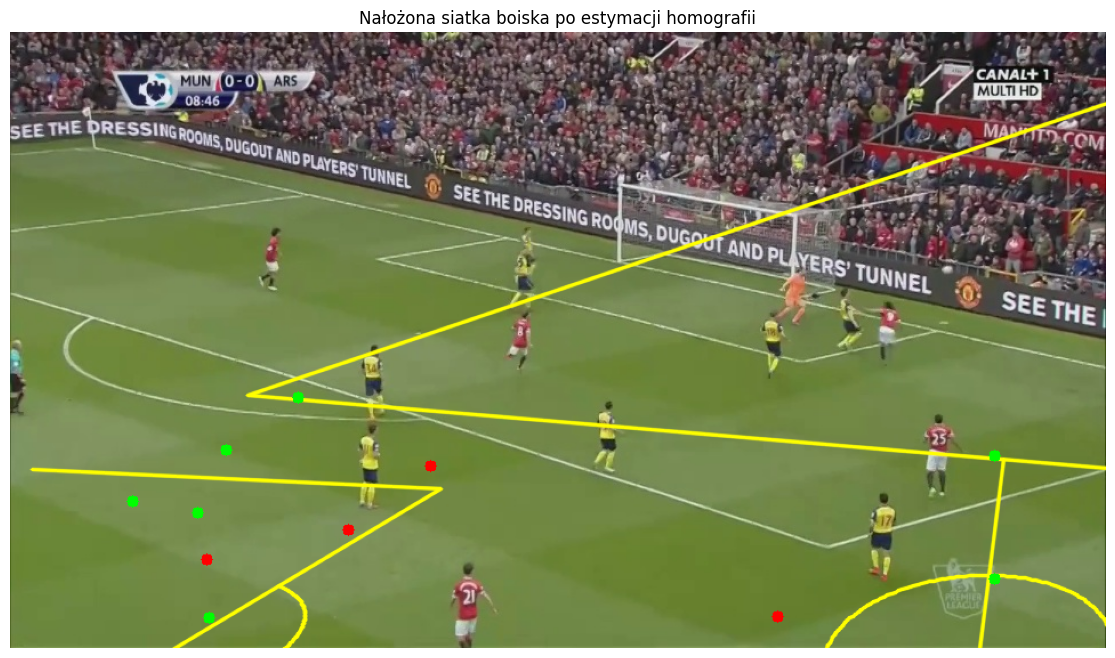

Zapisano: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\results\keypoints_visualization\pitch_grid_overlay.png


In [53]:
pitch_overlay = draw_pitch_overlay(image_rgb, H)

# Opcjonalnie: dorysuj inliery / outliery na obrazie z siatką
kp_grid_vis = pitch_overlay.copy()
confident_points = keypoints[confident_mask]
for local_idx, (x, y, conf) in enumerate(confident_points):
    pt = (int(round(x)), int(round(y)))
    color = (0, 255, 0) if inlier_mask[local_idx] else (255, 0, 0)
    cv2.circle(kp_grid_vis, pt, 5, color, -1)

plt.figure(figsize=(15, 8))
plt.imshow(kp_grid_vis)
plt.title('Nałożona siatka boiska po estymacji homografii')
plt.axis('off')
plt.show()

out_path = OUTPUT_DIR / 'pitch_grid_overlay.png'
cv2.imwrite(str(out_path), cv2.cvtColor(kp_grid_vis, cv2.COLOR_RGB2BGR))
print('Zapisano:', out_path)

## Wizualizacja zbiorcza

Na końcu zapisujemy jedną planszę z dwoma obrazami:
- po lewej: wykryte punkty charakterystyczne,
- po prawej: nałożony model boiska po estymacji homografii.

To jest najwygodniejsza wersja do użycia później w pracy lub do dalszego kadrowania.

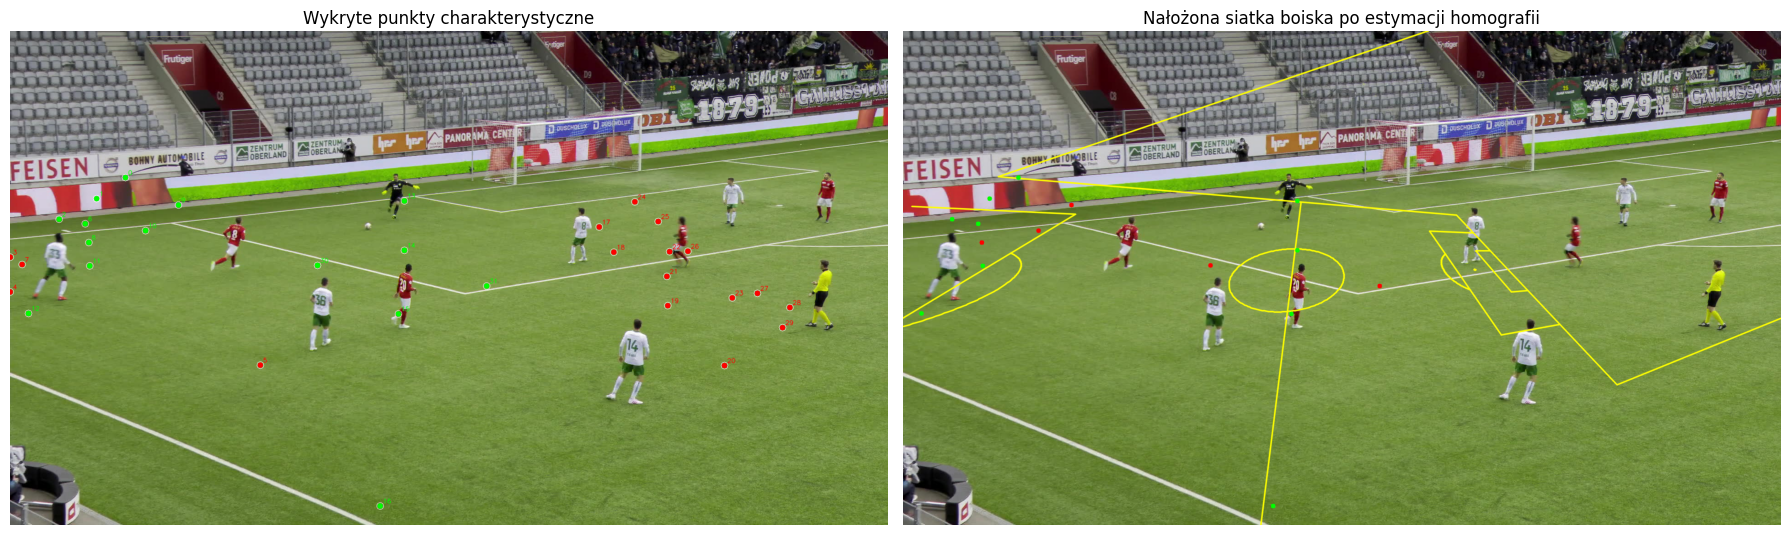

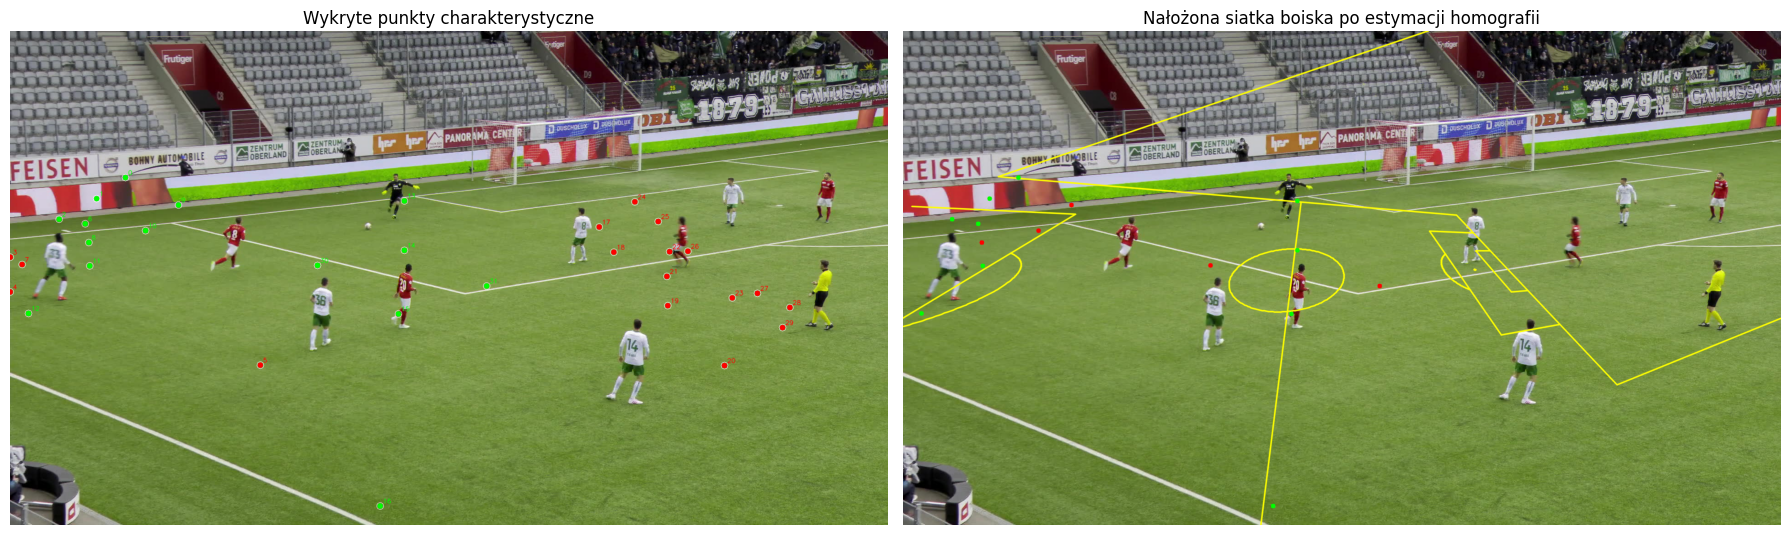

Zapisano: c:\Users\Gorze\Documents\MyFiles\STUDIA\Thesis\CvFootballTracker\results\keypoints_visualization\keypoints_and_pitch_grid_side_by_side.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(kp_vis)
axes[0].set_title('Wykryte punkty charakterystyczne')
axes[0].axis('off')

axes[1].imshow(kp_grid_vis)
axes[1].set_title('Nałożona siatka boiska po estymacji homografii')
axes[1].axis('off')

plt.tight_layout()
plt.show()

combined_path = OUTPUT_DIR / 'keypoints_and_pitch_grid_side_by_side.png'
fig.savefig(combined_path, dpi=200, bbox_inches='tight')
print('Zapisano:', combined_path)